# Parte I: El Camino de los Datos (Telco Churn)

# Trabajo Práctico 1 — Tecnología Digital VI

**Integrantes:** Facundo Arechaga, Franco Bergman, Peter Ahn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("DataSet.csv")

### 1. Introduccion al problema y Análisis Exploratorio

- i) El conjunto de datos Telco Customer Churn contiene informacion de clientes de una empresa de telecomunicaciones. Cada fila es un cliente y cada columna representa atributos de los mismos (caracteristicas demográficas, servicios contratados, datos de su cuenta, etc)

Hay muchas variables:
- customerID: Identificador único de cada cliente.
- gender: Género del cliente: Male o Female.
- SeniorCitizen: Indica si el cliente es adulto mayor: 1 = sí, 0 = no.
- Partner: Indica si el cliente tiene pareja: Yes o No.
- Dependents: Indica si el cliente tiene personas a cargo/dependientes: Yes o No.
- tenure_ Cantidad de meses que el cliente lleva en la empresa.
- PhoneService: Indica si el cliente tiene servicio telefónico.
- MultipleLines: Indica si el cliente tiene múltiples líneas telefónicas. Puede ser Yes, No o No phone service.
- InternetService: Tipo de servicio de internet contratado: DSL, Fiber optic o No.
- OnlineSecurity: Indica si tiene servicio de seguridad online.
- OnlineBackup: Indica si tiene servicio de backup online.
- DeviceProtection: Indica si tiene protección para sus dispositivos.
- TechSupport: Indica si tiene servicio de soporte técnico.
- StreamingTV: Indica si tiene servicio de televisión por streaming.
- StreamingMovies: Indica si tiene servicio de películas por streaming.
- Contract: Tipo de contrato del cliente: mensual, anual o de dos años.
- PaperlessBilling: Indica si utiliza facturación electrónica.
- PaymentMethod: Método de pago utilizado por el cliente, por ejemplo transferencia bancaria, tarjeta de crédito o cheque electrónico.
- MonthlyCharges: Monto que el cliente paga mensualmente por sus servicios.
- TotalCharges: Monto total que el cliente ha pagado durante todo el tiempo que lleva en la empresa.

La variable objetivo es Churn, que indica si el cliente abandonó o no la empresa durante el último mes.

El problema de negocio es identificar que clientes tienen mas posibilidades de abondonar la compañia, para poder anticiparse y lograr retenerlos. Asi la empresa podría hacer promociones, descuentos o mejoras en el servicio para los clientes con mas riesgo de churn.

In [2]:
df.head() # Mostramos las primeras filas del DataFrame para tener una vista previa de los datos cargados desde el archivo CSV.

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape # Muestra la cantidad de filas y columnas del DataFrame

(7043, 21)

In [4]:
df.info() # Muestra información general sobre el DataFrame, incluyendo el tipo de datos de cada columna y la cantidad de valores no nulos.

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Antes de entrenar cualquier modelo, revisamos los tipos de datos y la presencia de valores faltantes. Este paso permite detectar inconsistencias que podrían afectar el preprocesamiento posterior, como variables numéricas almacenadas como texto o valores faltantes no identificados correctamente.

In [5]:
df.isnull().sum() # Muestra la cantidad de valores nulos en cada columna del DataFrame.

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.describe() # Muestra estadísticas descriptivas de las columnas numéricas del DataFrame, como la media, desviación estándar, valores mínimo y máximo, y percentiles.

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


A continuación analizamos algunas variables relevantes para observar posibles relaciones con Churn. Estas visualizaciones no buscan demostrar causalidad, sino detectar patrones que puedan resultar útiles para comprender el problema y posteriormente entrenar los modelos.

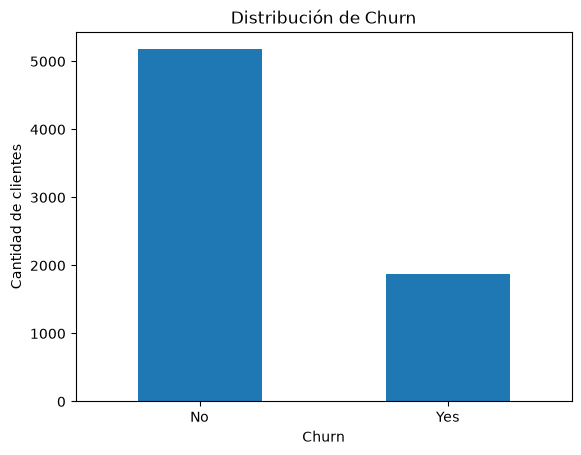

In [7]:
# Visualización de la distribución de la variable "Churn"

df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

La mayoría de los clientes no abandonó la empresa. Sin embargo, existe una cantidad considerable de clientes con Churn = Yes, por lo que el problema de abandono es relevante.

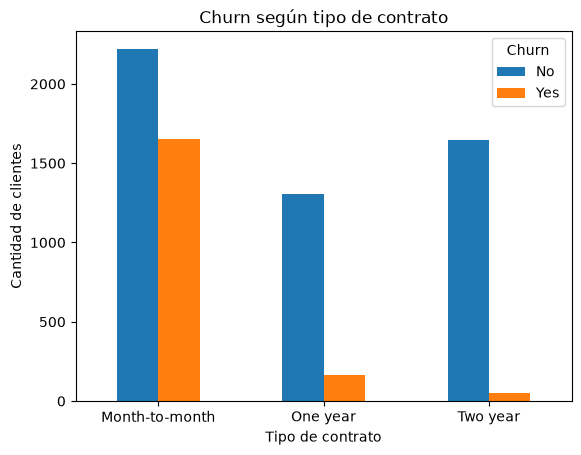

In [8]:
# Visualización de la relación entre "Contract" y "Churn"
pd.crosstab(df["Contract"], df["Churn"]).plot(kind="bar")

plt.title("Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

Los clientes con contrato Month-to-month presentan una cantidad mucho mayor de abandonos. En cambio, en los contratos de uno y dos años el churn es considerablemente menor.

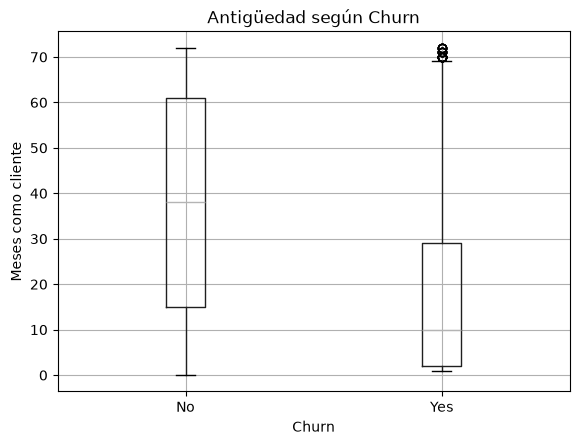

In [9]:
# Visualización de la relación entre "tenure" y "Churn"
df.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Antigüedad según Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Meses como cliente")
plt.show()

Los clientes que abandonan la empresa tienden a tener una menor antigüedad. Esto sugiere que los clientes más nuevos presentan mayor riesgo de churn.

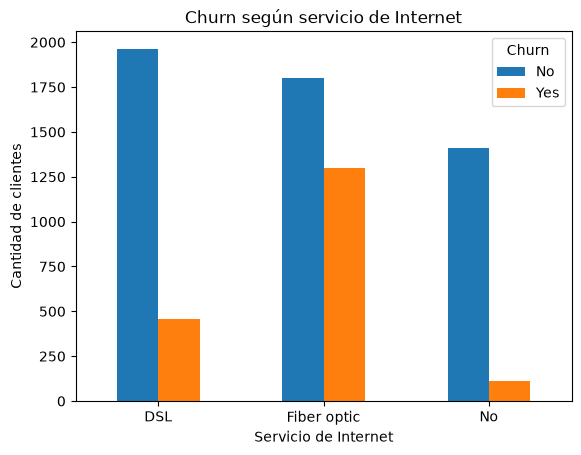

In [10]:
# Visualización de la relación entre "InternetService" y "Churn"
pd.crosstab(df["InternetService"], df["Churn"]).plot(kind="bar")

plt.title("Churn según servicio de Internet")
plt.xlabel("Servicio de Internet")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

Los clientes con Fiber optic presentan una mayor cantidad de abandonos que los clientes con DSL o sin servicio de internet. Esto sugiere que el tipo de servicio contratado podría estar relacionado con el churn.

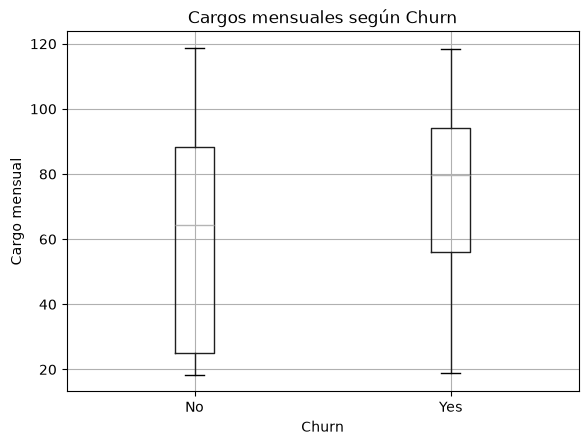

In [11]:
# Visualización de la relación entre "MonthlyCharges" y "Churn"
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Cargos mensuales según Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Cargo mensual")
plt.show()

Los clientes que abandonaron la empresa (Churn = Yes) tienden a tener cargos mensuales más altos que los clientes que permanecieron. La mediana de MonthlyCharges es mayor en el grupo con churn, lo que sugiere que el nivel de cargo mensual podría estar relacionado con la probabilidad de abandono.

In [12]:
df.dtypes # Muestra los tipos de datos de cada columna del DataFrame

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Se puede observar que la columna TotalCharges aparece como "str" cuando deberia representar un monto y por lo tanto ser numerica. Esto ocurre porque es interpretada como object ya que contiene valores vacios.

Si este problema no se detectara, la variable podría no ser utilizada correctamente por el modelo, generar errores durante el entrenamiento o ser interpretada como una variable categórica en lugar de numérica, afectando el desempeño del modelo.

In [13]:
# Convertimos la columna "TotalCharges" a tipo numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df["TotalCharges"].isna().sum())

df["TotalCharges"].dtype

11


dtype('float64')

### 2. Preprocesamiento y prevencion de Data Leakage

In [14]:
X = df.drop(columns=["Churn", "customerID"]) # Eliminamos las columnas "Churn" y "customerID" del DataFrame para crear un nuevo DataFrame X que contiene solo las características (features) que se utilizarán para el análisis o modelado.

y = df["Churn"].map({ # Convertimos la columna "Churn" a valores numéricos, donde "No" se mapea a 0 y "Yes" se mapea a 1. 
    "No": 0,
    "Yes": 1
})

- Separamos las variables predictoras de la variable objetivo, eliminando la columna a predecir ('Churn'). 
- Eliminamos la columna 'custumerID' ya que ID es un identificador arbitrario que no aporta poder predictivo.

- Aislamos la variable objetivo, y mapeamos las etiquetas 'Yes', 'No' en valores binarios (0,1)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

- Dividimos los datos en un conjunto de entrenamiento (X_train, y_train) con el 60% de los datos, un conjunto de validación (X_val, y_val) con el 20% y un conjunto de prueba (X_test, y_test) con el 20% restante.

- Ademas garantizamos que todos los conjuntos conserven la misma proporción de clientes que abandonaron y los que se quedaron (stratify=y).

In [16]:
categoricas = X_train.select_dtypes(include=["object", "string"]).columns
# Detectamos automáticamente todas las columnas cuyo tipo de datos sea 'object'.

numericas = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]
# Creamos una lista que contenga los nombres de las columnas cuyo tipo sea numérico, ya que
# luego a estas columnas se le aplicará el escalado.

binarias = ["SeniorCitizen"]
# Separamos la variable que ya viene codificada de forma binaria.

Separación en conjunto Train/Test:
La división de los datos en conjuntos de entrenamiento y testeo se realizó antes de cualquier operación de preprocesamiento, como la imputación de valores nulos, el escalado de variables numéricas.

A continuación, los parámetros de transformación (como la mediana, media, desviación estándar, etc.) se calculan sobre el conjunto de entrenamiento. Luego, estos parámetros se aplican (transform) sobre el conjunto de test.

Razón principal: Prevención de Data Leakage
Si hicierámos estos procedimientos en el orden inverso estaríamos introduciendo Data Leakage. 
Esto sucede porque las métricas de los datos de prueba terminarían contaminando el proceso de entrenamiento. 
Como consecuencia, el modelo obtendría métricas, que no reflejan la realidad y que fallan al introducir nuevos datos.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Guardamos los escaladores, que vamos a usar para comparar
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

mejores_resultados = {"nombre": None, "instancia": None, "accuracy": -1}

# 2. Hacemos un loop para evaluar cuál escalador obtiene el mejor desempeño 
# comparamos los scalers utilizando únicamente el conjunto de validación. El conjunto de test se reserva exclusivamente para la evaluación final del modelo y así evitamos Data Leakage.
for nombre, scaler in scalers.items():

    # Creamos un pipeline temporal para transformar los datos numéricos de train y validation

    pipe_temp = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler", scaler)
    ])

    # Seleccionamos las columnas numéricas para este test
    X_train_num = pipe_temp.fit_transform(X_train[numericas])
    X_val_num = pipe_temp.transform(X_val[numericas])
    
    # Entrenamos un modelo KNN base
    knn = KNeighborsClassifier()
    knn.fit(X_train_num, y_train)
    
    # Evaluamos usando Accuracy
    y_pred = knn.predict(X_val_num)
    score = accuracy_score(y_val, y_pred)
    
    if score > mejores_resultados["accuracy"]:
        mejores_resultados["accuracy"] = score
        mejores_resultados["nombre"] = nombre
        mejores_resultados["instancia"] = scaler

print(f"El mejor escalador fue: {mejores_resultados['nombre']} (Accuracy: {mejores_resultados['accuracy']:.4f})")

# 3. Asignamos el mejor escalador al pipeline_numericas
pipeline_numericas = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", mejores_resultados["instancia"])
])

pipeline_categoricas = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", pipeline_numericas, numericas),
    ("cat", pipeline_categoricas, categoricas),
    ("bin", "passthrough", binarias)
])

El mejor escalador fue: MinMaxScaler (Accuracy: 0.7665)


- Para las variables numericas:
    - Los valores faltantes aparecen principalmente en TotalCharges. En este dataset corresponden a clientes con una antigüedad muy baja o nula, por lo que utilizar 0 resulta razonable al representar que todavía no acumularon cargos históricos.
    - Luego se aplica el scaler seleccionado utilizando el conjunto de validación. El escalado es especialmente importante para KNN porque este modelo se basa en distancias: variables con escalas muy grandes podrían dominar el cálculo de distancia.

- Para las variables categoricas:
    - OneHotEncoder transforma texto en columnas de 0 y 1

In [18]:
X_train_proc = preprocessor.fit_transform(X_train) # Aplicamos el preprocesamiento a los datos de entrenamiento, ajustando el preprocesador a los datos de entrenamiento y transformándolos en un formato adecuado para el modelo.
X_val_proc = preprocessor.transform(X_val) # Aplicamos el preprocesamiento a los datos de validación, utilizando los parámetros ajustados con los datos de entrenamiento.

In [19]:
X_test_proc = preprocessor.transform(X_test) # Aplicamos el preprocesamiento a los datos de prueba utilizando el ColumnTransformer y almacenamos el resultado en X_test_proc.

In [20]:
print("Train original:", X_train.shape)
print("Train procesado:", X_train_proc.shape)

print("Test original:", X_test.shape)
print("Test procesado:", X_test_proc.shape)

Train original: (4225, 19)
Train procesado: (4225, 45)
Test original: (1409, 19)
Test procesado: (1409, 45)


Luego del preprocesamiento aumenta la cantidad de columnas porque OneHotEncoder transforma cada categoría de las variables categóricas en una nueva variable binaria. Por este motivo, aunque la cantidad de observaciones se mantiene, la cantidad de features del dataset procesado es mayor que en el dataset original.

El Train/Test Split debe realizarse antes de la imputación y del escalado. Luego de separar los datos, la imputación y el escalado se ajustan únicamente utilizando el conjunto de entrenamiento (fit) y posteriormente se aplican al conjunto de test (transform).

Si estas transformaciones se realizaran antes de dividir los datos, se estaría utilizando información del conjunto de test para preparar los datos de entrenamiento. Esto introduce Data Leakage, ya que el modelo tendría acceso indirectamente a información que debería permanecer desconocida hasta la evaluación final.

### 3. Estrategia de Validacion

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Definimos el modelo KNN con 25 vecinos
modelo = KNeighborsClassifier(n_neighbors=25)

# Definimos la validación cruzada con K-Fold, donde se divide el conjunto de datos en 5 folds y se realiza un entrenamiento y evaluación del modelo en cada pliegue.
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Función para realizar validación cruzada y calcular métricas
def validacion_cruzada(X, y, modelo, strat, preprocessor):
    scores = []

    for i, (train_index, val_index) in enumerate(strat.split(X, y)):

        # Separamos primero los folds
        X_train_fold = X.iloc[train_index]
        X_val_fold = X.iloc[val_index]

        y_train_fold = y.iloc[train_index]
        y_val_fold = y.iloc[val_index]

        # El preprocesamiento se ajusta SOLO con el fold de entrenamiento
        X_train_fold_proc = preprocessor.fit_transform(X_train_fold)

        # Validation solo se transforma
        X_val_fold_proc = preprocessor.transform(X_val_fold)

        # Entrenamos el modelo
        modelo.fit(X_train_fold_proc, y_train_fold)

        pred_train = modelo.predict(X_train_fold_proc)
        pred_val = modelo.predict(X_val_fold_proc)

        resultados = {
            "acc_train": accuracy_score(y_train_fold, pred_train),
            "acc_val": accuracy_score(y_val_fold, pred_val),
            "bacc_train": balanced_accuracy_score(y_train_fold, pred_train),
            "bacc_val": balanced_accuracy_score(y_val_fold, pred_val)
        }

        scores.append(resultados)

    return scores


Durante la validación cruzada, el preprocesamiento debe ajustarse nuevamente en cada fold utilizando únicamente la porción de entrenamiento correspondiente. De esta manera, el fold utilizado como validación no participa en el cálculo de la imputación, el escalado ni el encoding.

Esto evita Data Leakage y permite obtener una estimación más realista del rendimiento del modelo.

In [22]:
scores = validacion_cruzada(
    X_train,
    y_train,
    modelo,
    kf,
    preprocessor
)

df_resultados = pd.DataFrame(scores)

print("Resultados por Fold:")
display(df_resultados)

print("\nPromedio de las métricas (K-Fold Normal):")
display(df_resultados.mean())

Resultados por Fold:


,acc_train,acc_val,bacc_train,bacc_val
0,0.800296,0.782249,0.725754,0.715615
1,0.799112,0.791716,0.730601,0.715795
2,0.797041,0.781065,0.744916,0.704929
3,0.805917,0.779882,0.742640,0.714236
4,0.802071,0.776331,0.731347,0.702556



Promedio de las métricas (K-Fold Normal):


acc_train     0.800888
acc_val       0.782249
bacc_train    0.735052
bacc_val      0.710626
dtype: float64

Se utilizó validación cruzada con 5 folds sobre el conjunto de entrenamiento. A diferencia de una única partición Holdout, K-Fold permite evaluar el modelo varias veces utilizando diferentes subconjuntos como validación, obteniendo así una estimación más robusta y menos dependiente de una única división aleatoria.

Esto es especialmente importante en este dataset porque la variable objetivo Churn está desbalanceada: hay muchos más clientes que no abandonan el servicio que clientes que sí lo hacen. Por lo tanto, una única partición Holdout podría generar una muestra de validación con una proporción de clases poco representativa y producir una evaluación menos confiable.

In [23]:
from sklearn.model_selection import StratifiedKFold

# Definimos la validación cruzada con Stratified K-Fold, donde se divide el conjunto de datos en 5 folds estratificados, asegurando que la proporción de clases se mantenga en cada fold.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Realizamos la validación cruzada utilizando Stratified K-Fold y almacenamos los resultados en scores_stratified.
scores_stratified = validacion_cruzada(
    X_train,
    y_train,
    modelo,
    skf,
    preprocessor
)

df_resultados_strat = pd.DataFrame(scores_stratified)

print("Resultados por Fold:")
display(df_resultados_strat)

print("\nPromedio de las métricas (Stratified K-Fold):")
display(df_resultados_strat.mean())


Resultados por Fold:


,acc_train,acc_val,bacc_train,bacc_val
0,0.803254,0.790533,0.741118,0.719070
1,0.799112,0.810651,0.730466,0.754162
2,0.801183,0.801183,0.737216,0.726316
3,0.806805,0.779882,0.744602,0.707543
4,0.805325,0.757396,0.741264,0.686022



Promedio de las métricas (Stratified K-Fold):


acc_train     0.803136
acc_val       0.787929
bacc_train    0.738933
bacc_val      0.718623
dtype: float64

In [24]:
# Mostramos el porcentaje de cada clase en la columna "Churn"
print("Porcentaje por clase:")
print(df['Churn'].value_counts(normalize=True) * 100)

Porcentaje por clase:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


En este caso se utilizó Stratified K-Fold, ya que la variable objetivo Churn presenta un desbalance entre las clases Yes y No. La estratificación permite mantener aproximadamente la misma proporción de ambas clases en cada fold, evitando que alguna partición tenga una representación muy diferente de clientes que abandonan la empresa. En conclusion, seria conveniente utilizar Stratified K-Fold. 


### 4. Evaluacion del modelo base

Una vez seleccionados el escalador y el valor de k, unimos los conjuntos de entrenamiento y validación. Luego reajustamos el preprocesamiento y entrenamos el modelo final utilizando el 80% de los datos.

El conjunto de test permanece completamente separado y se utiliza una sola vez para obtener las métricas finales. De esta manera aprovechamos todos los datos disponibles para el entrenamiento sin introducir Data Leakage.

33
=== MÉTRICAS DEL MODELO BASE EN TEST ===
Accuracy:  0.7736
Precision: 0.5718
Recall:    0.5856
F1-Score:  0.5786


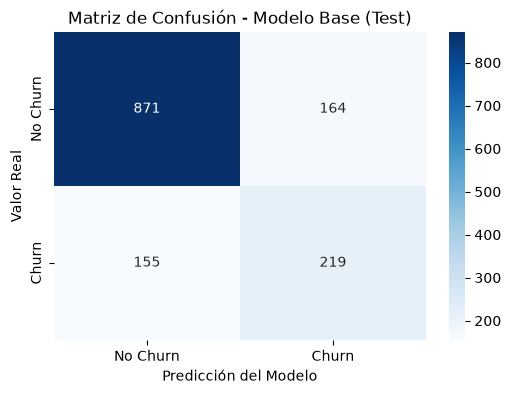

In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone
import seaborn as sns
import numpy as np

# 1. Definimos un rango de valores impares para K (ej. del 1 al 39)
k_valores = range(1, 40, 2)
resultados_cv = []

# 2. Realizamos la validación cruzada para cada valor de K utilizando Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Evaluamos el desempeño del modelo KNN para cada valor de K y almacenamos los resultados en la lista resultados_cv
for k in k_valores:

    pipeline_temp = Pipeline([
        ("preprocessor", preprocessor),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        pipeline_temp,
        X_train,
        y_train,
        cv=skf,
        scoring="balanced_accuracy"
    )

    resultados_cv.append(scores.mean())

# 4. Identificamos el valor de K que obtuvo el mejor desempeño en la validación cruzada
mejor_indice = np.argmax(resultados_cv)
mejor_k = k_valores[mejor_indice]
print(mejor_k)

# 5. Unimos entrenamiento y validación después de seleccionar el escalador y el valor de K
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

# Reajustamos el preprocesamiento utilizando todo el conjunto de desarrollo
preprocessor_final = clone(preprocessor)
X_train_final_proc = preprocessor_final.fit_transform(X_train_final)
X_test_final_proc = preprocessor_final.transform(X_test)

# Entrenamos el modelo final sobre entrenamiento y validación
modelo_final = KNeighborsClassifier(n_neighbors=mejor_k)
modelo_final.fit(X_train_final_proc, y_train_final)

y_predict = modelo_final.predict(X_test_final_proc)

accuracy = accuracy_score(y_test, y_predict)
precision = precision_score(y_test, y_predict)
recall = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)

print("=== MÉTRICAS DEL MODELO BASE EN TEST ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# 4. Matriz de Confusión Visual
cm = confusion_matrix(y_test, y_predict)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Modelo Base (Test)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()



En KNN, el k determina cuántos vecinos se consideran para realizar una predicción. Un valor muy pequeño puede hacer que el modelo sea demasiado sensible a observaciones particulares, mientras que uno demasiado grande puede suavizar demasiado la decisión.

Por este motivo, evaluamos distintos valores de k mediante Stratified K-Fold y seleccionamos el que obtiene la mayor Balanced Accuracy, ya que esta métrica tiene en cuenta el rendimiento sobre ambas clases y resulta útil frente al desbalance de Churn.

Observando el accuracy llegamos a la conclusion de que no es una buena metrica para nuestro problema (o en todo caso no es suficiente). Al tener un dataset desbalanceado, el accuracy queda sesgado e influenciado por la clase mayoritaria, que en este caso es "No Churn". 
Si implementaramos un modelo naive que prediga la clase mayoritaria tendriamos un accuracy aproximado a 73.46%, el mismo porcentaje de "No Churn" del dataset. De esta forma podemos ver que el modelo armado, al tener un accuracy mayor, suma un leve margen de aprendizaje, sin embargo, al tener un score cercano al del modelo naive concluimos en que no se puede confiar en la metrica.

### 5. Analisis de Negocio e Impacto de las Metricas

In [26]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, NearMiss

samples = {
    'Random_OS': RandomOverSampler(random_state=42),
    'SMOTE_OS': SMOTE(random_state=42),
    'ADASYN_OS': ADASYN(random_state=42),
    'Random_US': RandomUnderSampler(random_state=42),
    'NearMiss_US': NearMiss()
}

# Función para seleccionar la mejor técnica de muestreo basada en F1-Score
def mejor_sample_selection(samples, X_t, y_t, X_v, y_v, k):
    lista = []
    
    # Iteramos sobre cada técnica de muestreo en el diccionario samples
    for key in samples.keys():
        X_train_temp, y_train_temp = samples[key].fit_resample(X_t, y_t)

        m = KNeighborsClassifier(n_neighbors=k)
        
        m.fit(X_train_temp, y_train_temp)
        
        pred_train = m.predict(X_train_temp)
        pred_val = m.predict(X_v)
    
        res = {
            "samp": key,
            "acc_train": accuracy_score(y_train_temp, pred_train),
            "acc_val": accuracy_score(y_v, pred_val),
            "bacc_train": balanced_accuracy_score(y_train_temp, pred_train),
            "bacc_val": balanced_accuracy_score(y_v, pred_val),
            "f1_score": f1_score(y_v, pred_val)
        }
        print(res)
        lista.append(res)
    mejor_f1 = lista[0]
    for i in lista:
        if i["f1_score"] > mejor_f1["f1_score"]:
            mejor_f1 = i
    return mejor_f1["samp"]

mejor_sample = mejor_sample_selection(samples, X_train_proc, y_train, X_val_proc, y_val, mejor_k)
#print(mejor_sample)
sampler_final = clone(samples[mejor_sample])
X_train_balanceado, y_train_balanceado = sampler_final.fit_resample(X_train_final_proc, y_train_final)
    

{'samp': 'Random_OS', 'acc_train': 0.7604703608247423, 'acc_val': 0.6990773598296665, 'bacc_train': 0.7604703608247423, 'bacc_val': 0.751624945103206, 'f1_score': 0.6037383177570094}
{'samp': 'SMOTE_OS', 'acc_train': 0.772229381443299, 'acc_val': 0.6635911994322214, 'bacc_train': 0.772229381443299, 'bacc_val': 0.7360084218140484, 'f1_score': 0.5842105263157895}
{'samp': 'ADASYN_OS', 'acc_train': 0.7437802907915994, 'acc_val': 0.6288147622427254, 'bacc_train': 0.7443117947030486, 'bacc_val': 0.7234364101371774, 'f1_score': 0.5695473251028806}
{'samp': 'Random_US', 'acc_train': 0.756021409455843, 'acc_val': 0.6685592618878637, 'bacc_train': 0.7560214094558431, 'bacc_val': 0.7393900643261258, 'f1_score': 0.587819947043248}
{'samp': 'NearMiss_US', 'acc_train': 0.7020517395182873, 'acc_val': 0.5748757984386089, 'bacc_train': 0.7020517395182873, 'bacc_val': 0.651715363352192, 'f1_score': 0.5045492142266336}


Las distintas técnicas de muestreo se comparan utilizando el conjunto de validación, con el objetivo de seleccionar la alternativa que obtiene el mejor F1-Score.

Una vez elegida la mejor técnica, aplicamos el balanceo sobre la unión de entrenamiento y validación y volvemos a entrenar el modelo. Recién entonces evaluamos su rendimiento final sobre el conjunto de test. De esta manera, el test permanece separado del proceso de selección del modelo.

In [27]:
# Entrenamos el modelo final con el conjunto balanceado
modelo_balanceado = KNeighborsClassifier(n_neighbors=mejor_k)
modelo_balanceado.fit(X_train_balanceado, y_train_balanceado)

# Evaluamos sobre test
y_pred_balanceado = modelo_balanceado.predict(X_test_final_proc)

print("Accuracy:", accuracy_score(y_test, y_pred_balanceado))
print("Precision:", precision_score(y_test, y_pred_balanceado))
print("Recall:", recall_score(y_test, y_pred_balanceado))
print("F1-Score:", f1_score(y_test, y_pred_balanceado))

cm_balanceado = confusion_matrix(y_test, y_pred_balanceado)
print("Matriz de confusión:")
print(cm_balanceado)

Accuracy: 0.6855926188786373
Precision: 0.4503597122302158
Recall: 0.8368983957219251
F1-Score: 0.5855940130963517
Matriz de confusión:
[[653 382]
 [ 61 313]]


Luego de aplicar RandomOverSampler, el Accuracy disminuyó de 0.7736 a 0.6856. Sin embargo, el Recall aumentó considerablemente de 0.5856 a 0.8369, lo que indica que el modelo balanceado logra detectar una mayor proporción de clientes que realmente abandonan el servicio.

Este aumento del Recall viene acompañado de una caída en Precision, de 0.5718 a 0.4504, debido a que también aumentó la cantidad de falsos positivos. En términos de la matriz de confusión, los falsos negativos disminuyeron de 155 a 61, mientras que los falsos positivos aumentaron de 164 a 382.

Por lo tanto, el balanceo cambia el comportamiento del modelo: detecta muchos más casos reales de Churn, aunque a costa de generar más falsas alarmas.

En el caso del negocio planteado, un falso positivo significa ofrecerle un 50% de descuento a un cliente que en realidad no iba a abandonar el servicio, generando un costo innecesario para la empresa.

Por otro lado, un falso negativo significa no identificar a un cliente que realmente iba a abandonar, por lo que la empresa pierde la oportunidad de intentar retenerlo y corre el riesgo de perder los ingresos futuros asociados a ese cliente.

El costo relativo de ambos errores depende del valor económico del cliente y del costo del descuento, por lo que no puede afirmarse de manera general que uno sea siempre más costoso que el otro.

Si el descuento ofrecido por la empresa es muy costoso, conviene priorizar la Precision.

$$
Precision = \frac{TP}{TP + FP}
$$

Una Precision alta significa que, cuando el modelo predice que un cliente va a abandonar, tiene una mayor probabilidad de estar en lo correcto.

En este caso, como ofrecer el descuento tiene un costo elevado, interesa reducir los False Positives, ya que cada falso positivo representa un descuento otorgado innecesariamente a un cliente que igualmente se habría quedado


Si el descuento fuera muy barato o casi gratuito, convendría priorizar el Recall.

$$
Recall = \frac{TP}{TP + FN}
$$


Un Recall alto significa que el modelo logra detectar una mayor proporción de todos los clientes que realmente están por abandonar.

Si el descuento tiene un costo muy bajo, no resulta tan grave ofrecerlo a algunos clientes que en realidad no iban a irse. En ese caso, es preferible aceptar más falsos positivos con tal de reducir los False Negatives.

Esto también se puede observar en las matrices de confusión. El modelo base tuvo 164 falsos positivos y 155 falsos negativos, mientras que el modelo balanceado tuvo 382 falsos positivos y 61 falsos negativos.

Por lo tanto, el balanceo redujo considerablemente los falsos negativos, de 155 a 61, lo que explica el aumento del Recall de 0.5856 a 0.8369. Sin embargo, aumentó los falsos positivos, de 164 a 382, lo que hizo caer la Precision de 0.5718 a 0.4504.

Esto muestra claramente el trade-off entre Precision y Recall: el modelo balanceado detecta muchos más clientes que realmente abandonan, pero también genera más falsas alarmas.

## Parte II: Reformulando el Problema

Elegimos MonthlyCharges como nuevo target porque representa el nivel de gasto mensual del cliente. Como es una variable numérica, la transformamos en un problema de clasificación binaria utilizando la mediana como punto de corte. Los clientes con un gasto superior a la mediana se clasifican como HighMonthlyCharges = 1, mientras que los que tienen un gasto igual o inferior se clasifican como 0. Utilizamos la mediana porque permite separar el dataset en dos grupos de tamaño aproximadamente similar y es menos sensible a valores extremos que la media.

In [28]:

mediana_monthly = df["MonthlyCharges"].median() # Calculamos la mediana de la columna "MonthlyCharges" y la almacenamos en la variable mediana_monthly.
df["HighMonthlyCharges"] = (df["MonthlyCharges"] > mediana_monthly).astype(int) # Creamos una nueva columna "HighMonthlyCharges" en el DataFrame df, donde se asigna un valor de 1 si el valor de "MonthlyCharges" es mayor que la mediana y 0 en caso contrario. Esto nos permite identificar a los clientes con cargos mensuales altos.

Como HighMonthlyCharges fue construido directamente a partir de MonthlyCharges, no podemos utilizar MonthlyCharges como variable predictora.

Si la mantuviéramos dentro de X, el modelo tendría acceso prácticamente directo a la información utilizada para construir el target, generando target leakage y produciendo métricas artificialmente altas.

In [29]:

# Redefino X e Y para el nuevo problema
y_new = df["HighMonthlyCharges"]

X_new = df.drop(
    columns=[
        "HighMonthlyCharges",
        "MonthlyCharges", # Sacamos MonthlyCharges porque fue usada para crear el target. Dejarla sería data leakage.
        "Churn",
        "customerID"
    ]
)

In [30]:
from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42,
    stratify=y_new
)

In [31]:
# Ahora hay que redefinir qué columnas son numéricas y categóricas, porque MonthlyCharges ya no está entre las variables predictoras

numericas_new = [
    "tenure",
    "TotalCharges"
]

categoricas_new = X_train_new.select_dtypes(include=["object", "string"]).columns

binarias_new = ["SeniorCitizen"]

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


preprocessor_new = ColumnTransformer([ 
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler", StandardScaler())
    ]), numericas_new),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categoricas_new),

    ("bin", "passthrough", binarias_new)
])

In [33]:
X_train_new_proc = preprocessor_new.fit_transform(X_train_new)
X_test_new_proc = preprocessor_new.transform(X_test_new)

Para este segundo problema utilizamos KNeighborsClassifier con sus hiperparámetros por defecto, sin realizar una búsqueda adicional de configuración.

Esto permite evaluar de manera simple si el nuevo objetivo es predecible, tal como pide la consigna, sin optimizar específicamente el modelo para obtener mejores métricas.

In [34]:

modelo_new = KNeighborsClassifier() # Definimos un nuevo modelo KNN para el nuevo problema de clasificación, sin especificar k
modelo_new.fit(X_train_new_proc, y_train_new) # Entrenamos el modelo KNN con los datos de entrenamiento procesados y las etiquetas correspondientes para el nuevo problema de clasificación.
y_pred_new = modelo_new.predict(X_test_new_proc)

In [35]:
# Calculamos las métricas de desempeño del modelo para el nuevo target "HighMonthlyCharges"
accuracy_new = accuracy_score(y_test_new, y_pred_new)
balanced_accuracy_new = balanced_accuracy_score(y_test_new, y_pred_new)
precision_new = precision_score(y_test_new, y_pred_new)
recall_new = recall_score(y_test_new, y_pred_new)
f1_new = f1_score(y_test_new, y_pred_new)

print("=== MÉTRICAS NUEVO TARGET ===")
print(f"Accuracy:          {accuracy_new:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_new:.4f}")
print(f"Precision:         {precision_new:.4f}")
print(f"Recall:            {recall_new:.4f}")
print(f"F1-Score:          {f1_new:.4f}")

=== MÉTRICAS NUEVO TARGET ===
Accuracy:          0.9610
Balanced Accuracy: 0.9610
Precision:         0.9615
Recall:            0.9602
F1-Score:          0.9609


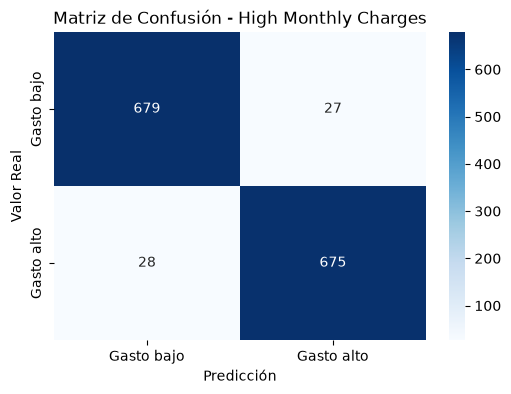

In [36]:
# Matriz de Confusión Visual para el nuevo target
cm_new = confusion_matrix(y_test_new, y_pred_new)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_new,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Gasto bajo", "Gasto alto"],
    yticklabels=["Gasto bajo", "Gasto alto"]
)

plt.title("Matriz de Confusión - High Monthly Charges")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

El nuevo objetivo resulta altamente predecible. El modelo obtuvo un Accuracy de 96,10%, una Balanced Accuracy de 96,10%, una Precision de 96,15%, un Recall de 96,02% y un F1-Score de 96,09%.

La matriz de confusión también muestra un rendimiento muy bueno: el modelo clasificó correctamente 679 clientes con gasto bajo y 675 con gasto alto, mientras que solo cometió 27 falsos positivos y 28 falsos negativos.

Como el target fue construido utilizando la mediana de MonthlyCharges, las clases están aproximadamente balanceadas, por lo que un modelo naive tendría un Accuracy cercano al 50%. Obtener aproximadamente 96% indica que las demás características del dataset contienen mucha información para distinguir entre clientes con gastos mensuales altos y bajos.

Aunque el nuevo objetivo resulta altamente predecible, este resultado debe interpretarse con cautela. TotalCharges está fuertemente relacionado con MonthlyCharges.

Por lo tanto, parte del alto rendimiento del modelo puede deberse a esta relación entre ambas variables y no necesariamente a que el resto de las características permitan predecir por sí solas si un cliente tiene cargos mensuales altos.

## Conclusiones

A lo largo del trabajo analizamos distintos modelos de clasificación utilizando el dataset Telco Customer Churn. En el problema original, vimos que existe un desbalance entre clientes que abandonan y clientes que permanecen. Esto genera que el Accuracy por sí solo no sea suficiente para evaluar correctamente los modelos.

También observamos la importancia de realizar correctamente el preprocesamiento de los datos, especialmente separando los conjuntos de entrenamiento y test antes de aplicar imputación, encoding y escalado. De esta forma se evita Data Leakage y se obtiene una evaluación más realista del modelo.

El uso de Cross Validation permitió obtener una estimación más robusta del desempeño del modelo que una única partición de validación. Además, Stratified K-Fold resultó más apropiado para el problema de Churn, ya que permite mantener aproximadamente la proporción de ambas clases en cada fold.

El modelo base de KNN obtuvo un Accuracy cercano al 77%, aunque un modelo naive que predijera siempre No Churn ya alcanzaría aproximadamente un 73,46%. Por lo tanto, la mejora observada en Accuracy es relativamente chica, lo que demuestra que esta métrica por sí sola puede resultar engañosa en un problema con clases desbalanceadas.

Al aplicar técnicas para tratar el desbalance de clases, comparamos distintos métodos de oversampling y undersampling. La técnica que obtuvo el mejor desempeño según F1-Score fue RandomOverSampler. Con el balanceo, el Accuracy disminuyó, pero esto no significa necesariamente que el modelo haya empeorado. Al darle mayor importancia a la clase Churn, el modelo logró mejorar su capacidad de detectar clientes que realmente podrían abandonar, aunque a cambio pudiera cometer más errores sobre la clase mayoritaria.

Además, desde el punto de vista del negocio, observamos que la elección de la métrica depende del costo asociado a los errores. Si ofrecer un descuento de retención es muy costoso, conviene priorizar Precision para reducir los falsos positivos y evitar ofrecer beneficios innecesarios a clientes que igualmente se habrían quedado. En cambio, si el descuento tiene un costo muy bajo, resulta más conveniente priorizar Recall, con el objetivo de detectar la mayor cantidad posible de clientes que realmente podrían abandonar.

Para el segundo problema predictivo definimos como nuevo objetivo si un cliente presenta un gasto mensual alto o bajo, utilizando la mediana de MonthlyCharges como punto de corte. En este caso, el modelo obtuvo resultados muy superiores: 96,10% de Accuracy, 96,10% de Balanced Accuracy, 96,15% de Precision, 96,02% de Recall y 96,09% de F1-Score.

Estos resultados indican que el nuevo target es altamente predecible a partir de las demás variables del dataset. Esto tiene sentido porque los distintos servicios contratados por los clientes están fuertemente relacionados con el monto que pagan mensualmente.

### Posibles mejoras futuras

En futuras iteraciones se podrían probar otras clases de modelos además de KNN. Por ejemplo, se podría comparar su desempeño con una Regresión Logística, un Árbol de Decisión o modelos de ensamble como Random Forest, ya que cada uno realiza supuestos distintos sobre la estructura de los datos y puede adaptarse mejor o peor al problema de Churn.

También se podría profundizar el proceso de Model Selection y optimización de hiperparámetros, evaluando distintas configuraciones de cada modelo mediante validación cruzada. Esto permitiría seleccionar no solamente el mejor valor de k para KNN, sino también comparar distintas configuraciones y modelos.

Otra posible mejora sería analizar con mayor detalle si los modelos presentan underfitting u overfitting, comparando su desempeño sobre entrenamiento y validación. Un modelo demasiado rígido puede no capturar correctamente los patrones de los datos, mientras que uno demasiado flexible puede ajustarse demasiado al conjunto de entrenamiento y generalizar mal frente a nuevos clientes.

También podría aplicarse Feature Engineering, creando nuevas variables a partir de las existentes para representar mejor relaciones relevantes del problema. En clase vimos que transformar o agregar features puede permitir que un modelo capture patrones que inicialmente no podía representar correctamente.

Por último, sería interesante evaluar modelos de ensamble, combinando varios modelos para intentar obtener predicciones más robustas que las de un único clasificador. En clasificación, una posibilidad vista en clase es combinar las predicciones mediante majority voting.

